# Hierarchical Planning

## Imports

In [1]:
import os
import time
import torch
import random
import minari
import numpy as np
import pprint

from dataclasses import dataclass
from torch import nn, Tensor
from torch.utils.data import DataLoader

# flow_matching
from flow_matching.path.scheduler import CondOTScheduler
from flow_matching.path import AffineProbPath
from flow_matching.solver import ODESolver
from flow_matching.utils import ModelWrapper

# visualization
import matplotlib.pyplot as plt
from matplotlib import cm

# training and evaluation
from src.run import (
    train
)

from src.pipelines.preprocessing import (
    collate_fn,
    get_dataset_stats,
    create_trajectory_chunks,
    create_normalized_chunks,
)
from src.pipelines.eval import (
    WrappedModel,
    WrappedConditionalModel,
    evaluate_open_loop,
    evaluate_policy_mpc,
)
from src.pipelines.sampling import generate_trajectory, unnormalize_trajectory
from src.models.backbone import MLP, CNN, ConditionalCNN, ConditionalUNet1D
from src.utils.loggers import WandBLogger

# visualization and evaluation
from src.pipelines.lunarlander.visualizers import visualize_trajectories as hvt
from src.pipelines.hopper.visualizers import visualize_trajectory as lvt

# To avoid meshgrid warning
import warnings

warnings.filterwarnings("ignore", category=UserWarning, module="torch")

if torch.cuda.is_available():
    device = "cuda:0"
    print("Using gpu")
else:
    device = "cpu"
    print("Using cpu.")
torch.manual_seed(42)
random.seed(42)
np.random.seed(42)

Using gpu


## Global Planner 

In [2]:
from src.pipelines.lunarlander.visualizers import visualize_dataset
from src.conf.environment import LunarLanderConfig

config = LunarLanderConfig()
minari_dataset = minari.load_dataset(dataset_id=config.dataset_name)
minari_dataset_stats = get_dataset_stats(minari_dataset)
minari_dataset_stats

{'obs_mean': tensor([-2.6158e-02,  4.6646e-01,  4.3395e-03, -2.2876e-01, -1.2054e-02,
         -6.0773e-05,  2.1673e-01,  2.1720e-01]),
 'obs_std': tensor([0.1075, 0.4694, 0.1949, 0.1756, 0.1438, 0.1310, 0.4120, 0.4123]),
 'act_mean': tensor([-0.1251, -0.0706]),
 'act_std': tensor([0.5542, 0.4226]),
 'rew_mean': tensor(268.9238),
 'rew_std': tensor(30.0081)}

### CCNN

In [ ]:
@dataclass
class LunarLanderArgs:
    environment: str = "LunarLander-v3"
    horizon: int = 100
    batch_size: int = 32
    num_epochs: int = 100
    print_every: int = 10
    lr: float = 1e-3
    hidden_dim: int = 64
    kernel_size: int = 5
    step_size: float = 0.05
    solver_method: str = "midpoint"
    inference_batch_size: int = 1
    condition_on: str = "start_obs_goal"
    model_type: str = "ccnn"
    device: str = "cuda:0" if torch.cuda.is_available() else "cpu"
    chunk_type: str = "obs_only"
args = LunarLanderArgs()

# Preparing the dataset
minari_dataset = minari.load_dataset(dataset_id=config.dataset_name)
action_dim = config.action_dim
obs_dim = config.obs_dim
input_dim = obs_dim * args.horizon
cond_dim = obs_dim * 2
minari_dataset_stats = get_dataset_stats(minari_dataset)
dataloader = DataLoader(minari_dataset, batch_size=args.batch_size, shuffle=True, collate_fn=collate_fn)

SAVE_DIR = "src/checkpoints"
run_name = f"{args.environment}_{args.model_type}_h{args.horizon}_e{args.num_epochs}_k{args.kernel_size}_{args.condition_on}"
MODEL_NAME = run_name + ".pth"
MODEL_SAVE_PATH = os.path.join(SAVE_DIR, MODEL_NAME)
pp = pprint.PrettyPrinter(indent=2)
print("Training configuration:")
pp.pprint(config)
pp.pprint(args)
print("Run name:", run_name)

logger = WandBLogger(
    config=args,
    run_name=run_name
)
model, stats, input_dim = train( 
    config=config, args=args, dataset=minari_dataset, logger=logger
)
env = minari_dataset.recover_environment()
evaluate_open_loop(env, model, stats, input_dim, args, logger=logger)
logger.finish()

Training configuration:
LunarLanderConfig(env_name='LunarLander-v3',
                  dataset_name='LunarLanderContinuous-v3/ppo-1000-deterministic-v1',
                  obs_dim=8,
                  action_dim=2)
LunarLanderArgs(environment='LunarLander-v3',
                horizon=100,
                batch_size=32,
                num_epochs=100,
                print_every=10,
                lr=0.001,
                hidden_dim=64,
                kernel_size=5,
                step_size=0.05,
                solver_method='midpoint',
                inference_batch_size=1,
                condition_on='start_obs_goal',
                model_type='ccnn',
                device='cuda:0',
                chunk_type='obs_only')
Run name: LunarLander-v3_ccnn_h100_e100_k5_start_obs_goal


Initializing WandB logger...


wandb: Currently logged in as: tsufanglu to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Input dimension for the model: 800
Training configuration:
LunarLanderConfig(env_name='LunarLander-v3',
                  dataset_name='LunarLanderContinuous-v3/ppo-1000-deterministic-v1',
                  obs_dim=8,
                  action_dim=2)
Run name: LunarLander-v3_ccnn_h100_e100_k5_start_obs_goal
Starting training...
| Epoch     10 | 7.00 s/epoch | Loss  0.39836 |
| Epoch     20 | 6.82 s/epoch | Loss  0.32663 |
| Epoch     30 | 6.79 s/epoch | Loss  0.29735 |
| Epoch     40 | 6.97 s/epoch | Loss  0.27433 |
| Epoch     50 | 6.81 s/epoch | Loss  0.26121 |
| Epoch     60 | 6.82 s/epoch | Loss  0.24950 |
| Epoch     70 | 6.91 s/epoch | Loss  0.24103 |
| Epoch     80 | 6.85 s/epoch | Loss  0.23792 |
| Epoch     90 | 7.11 s/epoch | Loss  0.23108 |
| Epoch    100 | 6.94 s/epoch | Loss  0.22822 |
Training complete. Saving model...
Saving src/checkpoints/LunarLander-v3_ccnn_h100_e100_k5_start_obs_goal.pth to WandB artifacts...
Model artifact saved.
Model saved to src/checkpoints/LunarL

RuntimeError: shape '[100, 10]' is invalid for input of size 800

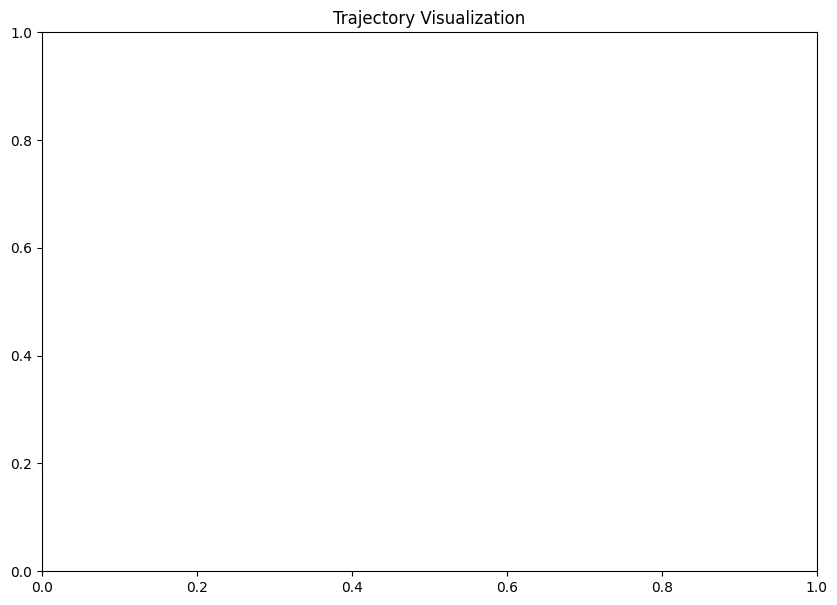

wandb: WARNING Fatal error while uploading data. Some run data will not be synced, but it will still be written to disk. Use `wandb sync` at the end of the run to try uploading.


In [ ]:
MODEL_SAVE_PATH = "src/checkpoints/LunarLander-v3_ccnn_h100_e100_k5_start_obs_goal.pth"


### UNet